In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import ot as pot
from tqdm import tqdm
import time
import torch.nn.functional as F

torch.manual_seed(42)
np.random.seed(42)

# Data Generation
def create_8_gaussians(n_samples: int = 10000):
    n_per_gaussian = n_samples // 8
    remainder = n_samples % 8
    radius = 2.0
    samples = []
    for i in range(8):
        n_current = n_per_gaussian + (1 if i < remainder else 0)
        angle = 2 * np.pi * i / 8
        mean = [radius * np.cos(angle), radius * np.sin(angle)]
        cov = [[0.05, 0], [0, 0.05]]
        gaussian_samples = np.random.multivariate_normal(mean, cov, n_current)
        samples.append(gaussian_samples)
    samples = np.concatenate(samples, axis=0)
    assert samples.shape[0] == n_samples, f"Expected {n_samples} samples, got {samples.shape[0]}"
    return torch.FloatTensor(samples)

def create_two_moons(n_samples: int = 10000):
    data, _ = make_moons(n_samples=n_samples, noise=0.05)
    data = data * 2 - 1
    return torch.FloatTensor(data)

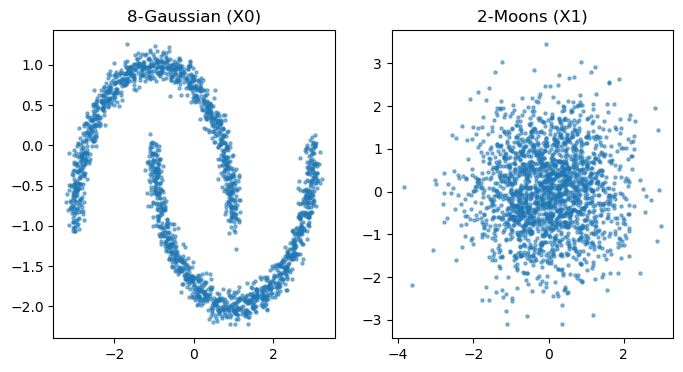

In [2]:
# Generate toy datasets: X0 (8-Gaussian) and X1 (2-Moons)
n_samples = 2000
X1 = torch.randn(n_samples, 2)
X0 = create_two_moons(n_samples)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title('8-Gaussian (X0)')
plt.scatter(X0[:,0], X0[:,1], s=5, alpha=0.5)
plt.subplot(1,2,2)
plt.title('2-Moons (X1)')
plt.scatter(X1[:,0], X1[:,1], s=5, alpha=0.5)
plt.show()

In [3]:
import sys, os
_meanflow_path = os.path.expanduser('~/projects/meanflow_inpainting/meanflow')
if _meanflow_path not in sys.path:
    sys.path.insert(0, _meanflow_path)
print('Added to sys.path:', _meanflow_path)

Added to sys.path: /home/bai195/projects/meanflow_inpainting/meanflow


In [4]:
from models.meanflow import MeanFlow

In [5]:
from models.meanflow import MeanFlow
from models.mf_model import MFModel, BranchMLP

# backbone MLP config (no input_dim/output_dim — MFModel injects them)
net_config = dict(hidden_dim=128, num_hidden_layers=4, use_residual=True)

# MFModel wrapper config — must be a dict, not a class
wrapper_configs = dict(
    shapes=(2,),          # data shape per sample, (2,) for 2-D toy
    time_embed_dim=16,       # TimestepEmbedder output dim H
    net_arch=BranchMLP,
    net_config=net_config,
)

class Args:
    ema_decay = 0.999
    ema_decays = [0.99, 0.999]
    norm_eps = 1e-6
    norm_p = 0.75
    case = 'base'         # 'base' or 'ot'
    ot_method = 'exact'
    tr_sampler = 'v1'
    lr = 0.0006
    P_mean_t = -0.6
    P_std_t = 1.6
    P_mean_r = -4.0
    P_std_r = 1.6
    warmup_epochs = 200
    ratio = 0.75
    
    version= 'imf' # or imf, x-pixel, mf 

args = Args()

model = MeanFlow(MFModel, args, wrapper_configs)
print(model.net)

MFModel(
  (time_embedder): TimestepEmbedder(
    (mlp): Sequential(
      (0): Linear(in_features=16, out_features=16, bias=True)
      (1): SiLU()
      (2): Linear(in_features=16, out_features=16, bias=True)
    )
  )
  (net): BranchMLP(
    (in_proj): Linear(in_features=34, out_features=128, bias=True)
    (in_act): ReLU()
    (blocks): ModuleList(
      (0-3): 4 x _ResidualBlock(
        (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (fc1): Linear(in_features=128, out_features=128, bias=True)
        (act): ReLU()
        (fc2): Linear(in_features=128, out_features=128, bias=True)
        (drop): Identity()
      )
    )
    (out_proj): Linear(in_features=128, out_features=2, bias=True)
  )
)


Epoch 0, Loss: 1.3407


RuntimeError: The size of tensor a (2) must match the size of tensor b (2000) at non-singleton dimension 1

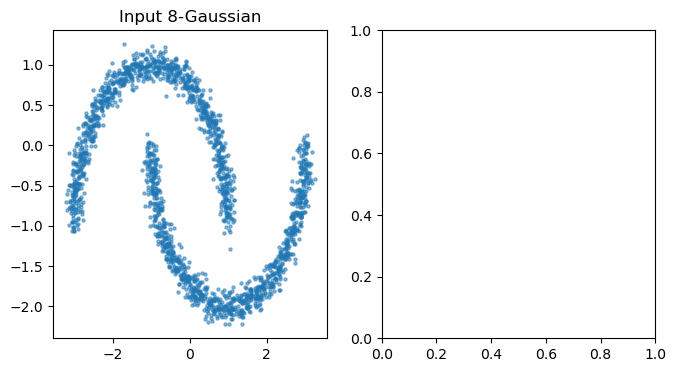

In [6]:
# Train MeanFlow on toy example (8-Gaussian to 2-Moons) with batch size
import torch
import matplotlib.pyplot as plt

# Prepare data


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
n_epochs = 1000
batch_size = 100
num_batches = n_samples // batch_size

time_st=time.time()
for epoch in range(n_epochs):
    perm = torch.randperm(n_samples)
    epoch_loss = 0.0
    for i in range(num_batches):
        idx = perm[i*batch_size:(i+1)*batch_size]
        x1_batch = X1[idx]
        x0_batch = X0[idx]
        # You can also use x1_batch = X1[idx] for aug_cond if needed
        optimizer.zero_grad()
        loss = model.forward_with_loss(x0=x0_batch,x1=x1_batch,aug_cond=None,)
        loss.backward()
        optimizer.step()
        model.update_ema()
        epoch_loss += loss.item()
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {epoch_loss/num_batches:.4f}")
    if epoch % 200== 0: 
        # Sample from trained model
        with torch.no_grad():

            # Plot results
            plt.figure(figsize=(12,4))
            plt.subplot(1,3,1)
            plt.title('Input 8-Gaussian')
            plt.scatter(X0[:,0], X0[:,1], s=5, alpha=0.5)
            plt.subplot(1,3,2)
            samples = model.sample(x1=X1,T=1)
            plt.title('MeanFlow Samples 1 step')   
            plt.scatter(samples[:,0], samples[:,1], s=5, alpha=0.5)

            plt.subplot(1,3,3)
            samples = model.sample((n_samples, 2), device=X1.device,x1=X1,T=2)
            plt.title('MeanFlow Samples 2 step')   
            plt.scatter(samples[:,0], samples[:,1], s=5, alpha=0.5)

            plt.show()

time_end=time.time()
run_time=time_end-time_st 
print('run time is',run_time)
torch.save(model.state_dict(), name+'.pt')


In [9]:
import ot
def wasserstein_error(X1,X1_hat):
    M=ot.dist(X1,X1_hat)
    M=M.detach().cpu().numpy()
    n,m=X1.shape[0],X1_hat.shape[0]
    p,q=np.ones(n)/n,np.ones(m)/m
    pi=ot.emd(p,q,M,numItermax=1e7)
    cost=np.sum(M*pi)
    return cost 



In [10]:
import matplotlib.pyplot as plt
with torch.no_grad():
    # 1 step
    samples_1step = model.sample((n_samples, 2),net=model.net_ema, device=X0.device, e=X0, T=1)
    err1=wasserstein_error(X1,samples_1step)
    # 2 step
    samples_2step = model.sample((n_samples, 2),net=model.net_ema, device=X0.device, e=X0, T=2)
    err2=wasserstein_error(X1,samples_2step)


plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title('Target X1')
plt.scatter(X1[:,0], X1[:,1], s=2, alpha=0.5)

plt.subplot(1,3,2)

plt.title('MeanFlow 1-step, W2 error=%.6f'% err1)
plt.scatter(samples_1step[:,0], samples_1step[:,1], s=2, alpha=0.5)

plt.subplot(1,3,3)
plt.title('MeanFlow 2-step, W2 error=%.6f'% err2)
plt.scatter(samples_2step[:,0], samples_2step[:,1], s=2, alpha=0.5)

plt.tight_layout()
plt.show()

In [75]:
model.net

In [76]:
model.net_ema

In [ ]:
with torch.no_grad():
    samples = model.sample((n_samples, 2), device=X0.device,e=X0)
    # Plot results
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.title('Input Gaussian')
    plt.scatter(X0[:,0], X0[:,1], s=3, alpha=0.5)
    plt.subplot(1,2,2)
    plt.title('MeanFlow Samples')
    plt.scatter(samples[:,0], samples[:,1], s=3, alpha=0.5)
    plt.show()

In [ ]:
replace=False
# Flatten the coupling matrix

pi_flat = pi.flatten()
# Sample according to the distribution
indices = torch.multinomial(torch.from_numpy(pi_flat), batch_size, replacement=replace)
# Convert flat indices back to (i, j) pairs
i_indices = indices // pi.shape[1]
j_indices = indices % pi.shape[1]

In [ ]:
i_indices

In [ ]:
j_indices

In [ ]:
x1=x[i_indices]
e1=e[j_indices]
torch.norm(x1-e1,dim=1).mean()

In [ ]:
torch.norm(x_ot-e_ot,dim=1).mean()

In [ ]:
import matplotlib.pyplot as plt
with torch.no_grad():
    # 一步生成
    samples_1step = model.sample((n_samples, 2), device=X0.device, e=X0, T=1)
    # 两步生成
    samples_2step = model.sample((n_samples, 2), device=X0.device, e=X0, T=2)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title('Target (X1)')
plt.scatter(X1[:,0], X1[:,1], s=5, alpha=0.5)

plt.subplot(1,3,2)
plt.title('MeanFlow 1-step')
plt.scatter(samples_1step[:,0], samples_1step[:,1], s=5, alpha=0.5)

plt.subplot(1,3,3)
plt.title('MeanFlow 2-step')
plt.scatter(samples_2step[:,0], samples_2step[:,1], s=5, alpha=0.5)

plt.tight_layout()
plt.show()